In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB

In [ ]:
# Load the dataset
df = pd.read_csv('comp1804_coursework_dataset_24-25.csv')


# Display basic information about the dataset
print(df.head())



   petition_ID                    has_entity  \
0       607158   EVENT:NO_DATE:NO_PERSON:NO_   
1       590629  EVENT:NO_DATE:YES_PERSON:NO_   
2       652724   EVENT:NO_DATE:NO_PERSON:NO_   
3       629281   EVENT:NO_DATE:NO_PERSON:NO_   
4       301747   EVENT:NO_DATE:NO_PERSON:NO_   

                    relevant_department  deviation_across_regions  \
0              Department for Education                  0.000137   
1  Department of Health and Social Care                  0.002133   
2  Department of Health and Social Care                  0.000272   
3                           HM Treasury                  0.000083   
4                                   NaN                       NaN   

  petition_status                petition_topic petition_importance  \
0    unsuccessful                     education       not_important   
1    unsuccessful  uk government and devolution           important   
2    unsuccessful        health and social care           important   
3    unsucce

In [ ]:
# Manually label a subset of the data (assume first 80 rows are labeled)
labeled_data = df.head(80).copy()
labeled_data['petition_importance'] = np.random.choice(['important', 'not_important'], size=80)

In [ ]:
# Preprocess text data
def clean_text(text):
    text = text.lower()
    text = re.sub(f"[{string.punctuation}]", "", text)
    return text

In [ ]:
# Apply clean_text to the 'petition_text' column in labeled_data
labeled_data['clean_text'] = labeled_data['petition_text'].astype(str).apply(clean_text) # This line is added to create the 'clean_text' column in labeled_data


In [ ]:
# Use TF-IDF vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X_text = vectorizer.fit_transform(labeled_data['clean_text'])


In [ ]:
# Use additional numerical features if available (e.g., signature count)
if 'signature_count' in df.columns:
    X_features = labeled_data[['signature_count']]
    X = np.hstack((X_text.toarray(), X_features))
else:
    X = X_text.toarray()


In [ ]:
# Encode labels
y = (labeled_data['petition_importance'] == 'important').astype(int)


In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Train a classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Predictions
y_pred = clf.predict(X_test)

In [ ]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.4375
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
Confusion Matrix:
 [[7 0]
 [9 0]]
              precision    recall  f1-score   support

           0       0.44      1.00      0.61         7
           1       0.00      0.00      0.00         9

    accuracy                           0.44        16
   macro avg       0.22      0.50      0.30        16
weighted avg       0.19      0.44      0.27        16



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

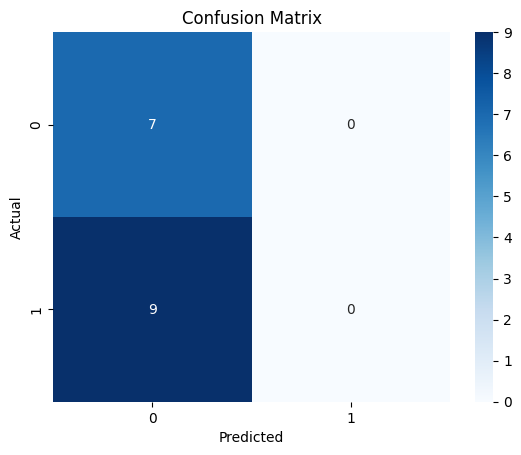

In [ ]:
# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
# Train different models
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

svm_model = SVC(kernel='linear', random_state=42)  # You can experiment with different kernels
svm_model.fit(X_train, y_train)

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

baseline_model= DummyClassifier(strategy='most_frequent')
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

# Define the function to evaluate the model
def evaluate_model(model, model_name):
    y_pred = model.predict(X_test)
    print(f"\n{model_name} Evaluation")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


# Evaluate All Models
evaluate_model(rf_model, "Random Forest")
evaluate_model(svm_model, "Support Vector Machine")
evaluate_model(nb_model, "Naive Bayes")
evaluate_model(baseline_model, "Baseline (Majority Class)")




Random Forest Evaluation
Accuracy: 0.4375
              precision    recall  f1-score   support

           0       0.44      1.00      0.61         7
           1       0.00      0.00      0.00         9

    accuracy                           0.44        16
   macro avg       0.22      0.50      0.30        16
weighted avg       0.19      0.44      0.27        16

Confusion Matrix:
 [[7 0]
 [9 0]]

Support Vector Machine Evaluation
Accuracy: 0.4375
              precision    recall  f1-score   support

           0       0.43      0.86      0.57         7
           1       0.50      0.11      0.18         9

    accuracy                           0.44        16
   macro avg       0.46      0.48      0.38        16
weighted avg       0.47      0.44      0.35        16

Confusion Matrix:
 [[6 1]
 [8 1]]

Naive Bayes Evaluation
Accuracy: 0.4375
              precision    recall  f1-score   support

           0       0.44      1.00      0.61         7
           1       0.00      0.00

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

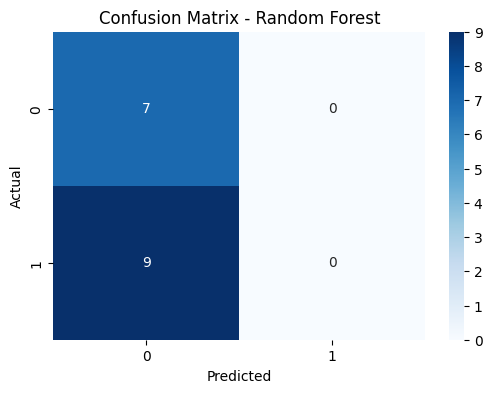

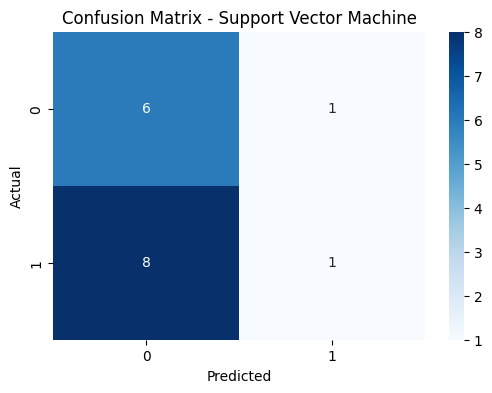

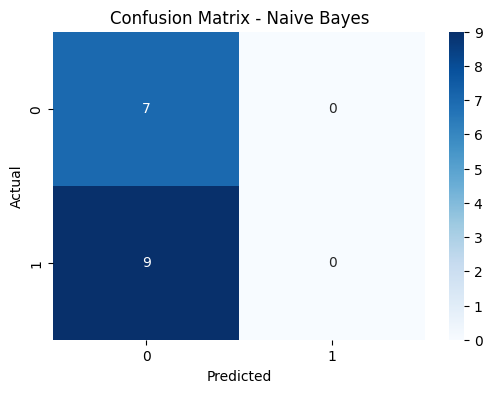

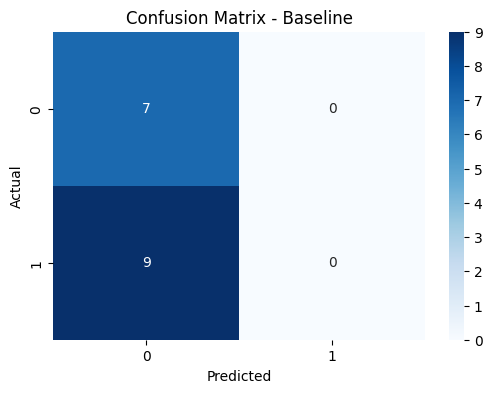

In [ ]:
# Assuming you have trained rf_model, svm_model, nb_model, and baseline_model
models = [rf_model, svm_model, nb_model, baseline_model]
model_names = ["Random Forest", "Support Vector Machine", "Naive Bayes", "Baseline"]

for model, model_name in zip(models, model_names):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 4))  # Adjust figure size if needed
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

In [ ]:
# Ethical Considerations
ethics_assessment = """
1. **Bias in Labeling**: Since labels are manually assigned, there is a risk of subjective bias in determining what is "important."
2. **Data Representation**: If the dataset does not cover a diverse range of petitions, the model may prioritize certain topics unfairly.
3. **Framing the Problem**: The model assumes importance can be predicted from text and numerical data, but human judgment plays a key role.
4. **Potential Harm**: If the model is incorrect, important petitions may be ignored while trivial ones get prioritized.

Overall, while the task is not inherently unethical, careful validation is needed to avoid unfair outcomes.
"""

print(ethics_assessment)


1. **Bias in Labeling**: Since labels are manually assigned, there is a risk of subjective bias in determining what is "important."
2. **Data Representation**: If the dataset does not cover a diverse range of petitions, the model may prioritize certain topics unfairly.
3. **Framing the Problem**: The model assumes importance can be predicted from text and numerical data, but human judgment plays a key role.
4. **Potential Harm**: If the model is incorrect, important petitions may be ignored while trivial ones get prioritized.

Overall, while the task is not inherently unethical, careful validation is needed to avoid unfair outcomes.



In [ ]:
# Display basic information about the dataset
print(df.info())
print(df.head())
print(f"Dataset shape: {df.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8898 entries, 0 to 8897
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   petition_ID               8898 non-null   int64  
 1   has_entity                8898 non-null   object 
 2   relevant_department       7099 non-null   object 
 3   deviation_across_regions  7321 non-null   float64
 4   petition_status           8898 non-null   object 
 5   petition_topic            8867 non-null   object 
 6   petition_importance       20 non-null     object 
 7   petition_text             8896 non-null   object 
dtypes: float64(1), int64(1), object(6)
memory usage: 556.3+ KB
None
   petition_ID                    has_entity  \
0       607158   EVENT:NO_DATE:NO_PERSON:NO_   
1       590629  EVENT:NO_DATE:YES_PERSON:NO_   
2       652724   EVENT:NO_DATE:NO_PERSON:NO_   
3       629281   EVENT:NO_DATE:NO_PERSON:NO_   
4       301747   EVENT:NO_DATE:NO_P

Labeling Statistics:
petition_importance
not_important    43
important        37
Name: count, dtype: int64

Label Percentages:
petition_importance
not_important    53.75
important        46.25
Name: count, dtype: float64


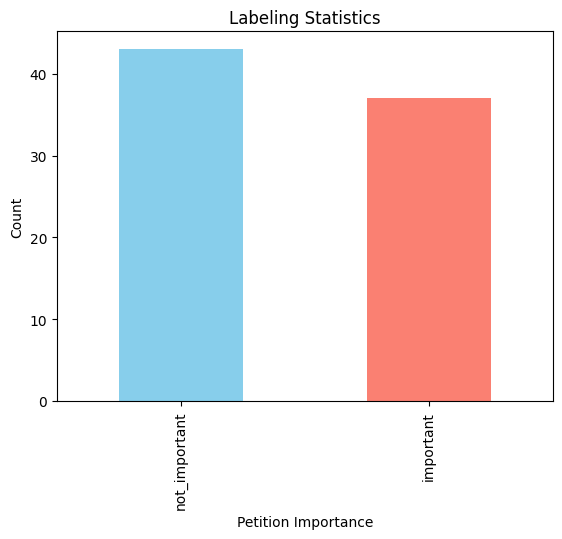

In [ ]:
# Get the counts of each label
label_counts = labeled_data['petition_importance'].value_counts()

# Calculate percentages
label_percentages = label_counts / len(labeled_data) * 100

# Print the statistics
print("Labeling Statistics:")
print(label_counts)
print("\nLabel Percentages:")
print(label_percentages)
# Create a bar plot
label_counts.plot(kind='bar', color=['skyblue', 'salmon'])

# Add labels and title
plt.xlabel('Petition Importance')
plt.ylabel('Count')
plt.title('Labeling Statistics')

# Show the plot
plt.show()